In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, f1_score,)
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
flights_df = pd.read_csv("flight_delay_model_ready.csv")
print("Dataset loaded:", flights_df.shape)
flights_df.head(3)

Dataset loaded: (5332914, 38)


,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_TIME,TAXI_OUT,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,AIR_SYSTEM_DELAY,...,AIRLINE_MQ,AIRLINE_NK,AIRLINE_OO,AIRLINE_UA,AIRLINE_US,AIRLINE_VX,AIRLINE_WN,SEASON_Spring,SEASON_Summer,SEASON_Winter
0,1,1,4,5,2354.0,21.0,205.0,1448,430,0.0,...,False,False,False,False,False,False,False,False,False,True
1,1,1,4,10,2.0,12.0,280.0,2330,750,0.0,...,False,False,False,False,False,False,False,False,False,True
2,1,1,4,20,18.0,16.0,286.0,2296,806,0.0,...,False,False,False,False,True,False,False,False,False,True


In [ ]:
leak_cols = ["AIRLINE_DELAY", "WEATHER_DELAY", "LATE_AIRCRAFT_DELAY", "AIR_SYSTEM_DELAY", "SECURITY_DELAY"]
X = flights_df.drop(columns=["DELAY_RISK"] + leak_cols, errors="ignore")
y = flights_df["DELAY_RISK"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train size : {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test size  : {X_test.shape[0]:,} rows")
print(f"Target balance (train): {y_train.value_counts(normalize=True).round(3).to_dict()}")
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
feature_names = X.columns.tolist()
print("\nFeatures going into model:", feature_names)

Train size : 4,266,331 rows, 32 features
Test size  : 1,066,583 rows
Target balance (train): {0: 0.82, 1: 0.18}

Features going into model: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'IS_PEAK_HOUR', 'IS_WEEKEND', 'IS_LATE_NIGHT', 'IS_LONG_HAUL', 'EARLY_MORNING_FLIGHT', 'IS_MAJOR_HUB', 'DEPARTURE_HOUR', 'AIRLINE_AS', 'AIRLINE_B6', 'AIRLINE_DL', 'AIRLINE_EV', 'AIRLINE_F9', 'AIRLINE_HA', 'AIRLINE_MQ', 'AIRLINE_NK', 'AIRLINE_OO', 'AIRLINE_UA', 'AIRLINE_US', 'AIRLINE_VX', 'AIRLINE_WN', 'SEASON_Spring', 'SEASON_Summer', 'SEASON_Winter']


### Baseline model

- Logistic regression provides our performance floor. Key metrics to focus on are recall (catching as many actual delays as possible) and F1-score (balance of precision and recall), not raw accuracy because the classes are imbalanced, accuracy is misleading.

In [7]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train_sc, y_train)

y_pred_lr   = lr.predict(X_test_sc)
y_prob_lr   = lr.predict_proba(X_test_sc)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION — BASELINE")
print("=" * 50)
print(classification_report(y_test, y_pred_lr,
      target_names=["On Time", "Delayed"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lr):.4f}")

LOGISTIC REGRESSION — BASELINE
              precision    recall  f1-score   support

     On Time       0.92      0.70      0.80    874418
     Delayed       0.35      0.72      0.47    192165

    accuracy                           0.71   1066583
   macro avg       0.63      0.71      0.63   1066583
weighted avg       0.82      0.71      0.74   1066583

ROC-AUC : 0.7829
F1 Score: 0.4677


### Improved model 

- Why Random Forest: It handles class imbalance natively with class_weight, requires no scaling, is robust to outliers, and produces interpretable feature importances. Which is ideal for an operational decision-support project like this. It will very likely outperform logistic regression on your data.


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_rf,
      target_names=["On Time", "Delayed"]))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

     On Time       0.96      0.78      0.86    874418
     Delayed       0.46      0.85      0.60    192165

    accuracy                           0.79   1066583
   macro avg       0.71      0.81      0.73   1066583
weighted avg       0.87      0.79      0.81   1066583

ROC-AUC : 0.9068
F1 Score: 0.5961


### Compare & Evalute

In [9]:
from sklearn.metrics import precision_score, recall_score

results = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Random Forest"],
    "ROC-AUC": [
        round(roc_auc_score(y_test, y_prob_lr), 4),
        round(roc_auc_score(y_test, y_prob_rf), 4)
    ],
    "F1 Score": [
        round(f1_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_rf), 4)
    ],
    "Precision": [
        round(precision_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_rf), 4)
    ],
    "Recall": [
        round(recall_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_rf), 4)
    ],
})

print(results.to_string(index=False))
print("\nSelected model: Random Forest")
print("Reason: Higher ROC-AUC and F1 score with better recall on delayed class.")

                         Model  ROC-AUC  F1 Score  Precision  Recall
Logistic Regression (baseline)   0.7829    0.4677     0.3466  0.7190
                 Random Forest   0.9068    0.5961     0.4602  0.8458

Selected model: Random Forest
Reason: Higher ROC-AUC and F1 score with better recall on delayed class.


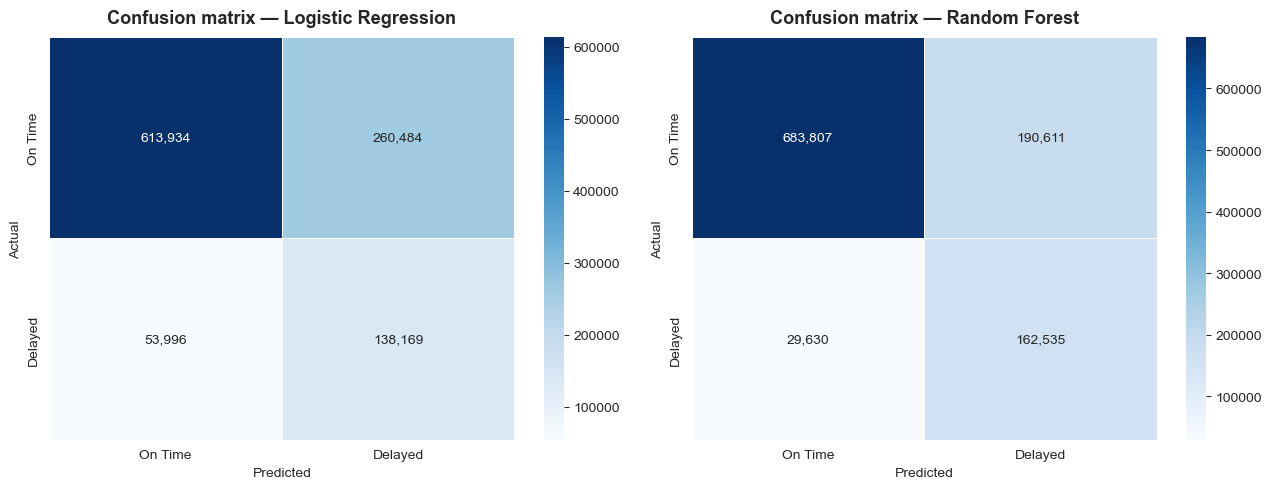


Random Forest breakdown:
  True Positives  (correctly caught delays): 162,535
  False Negatives (missed delays):           29,630
  False Positives (false alarms):            190,611
  True Negatives  (correctly cleared):       683,807


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
                xticklabels=["On Time", "Delayed"],
                yticklabels=["On Time", "Delayed"],
                ax=ax, linewidths=0.5)
    ax.set_title(f"Confusion matrix — {title}",
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f"\nRandom Forest breakdown:")
print(f"  True Positives  (correctly caught delays): {tp:,}")
print(f"  False Negatives (missed delays):           {fn:,}")
print(f"  False Positives (false alarms):            {fp:,}")
print(f"  True Negatives  (correctly cleared):       {tn:,}")

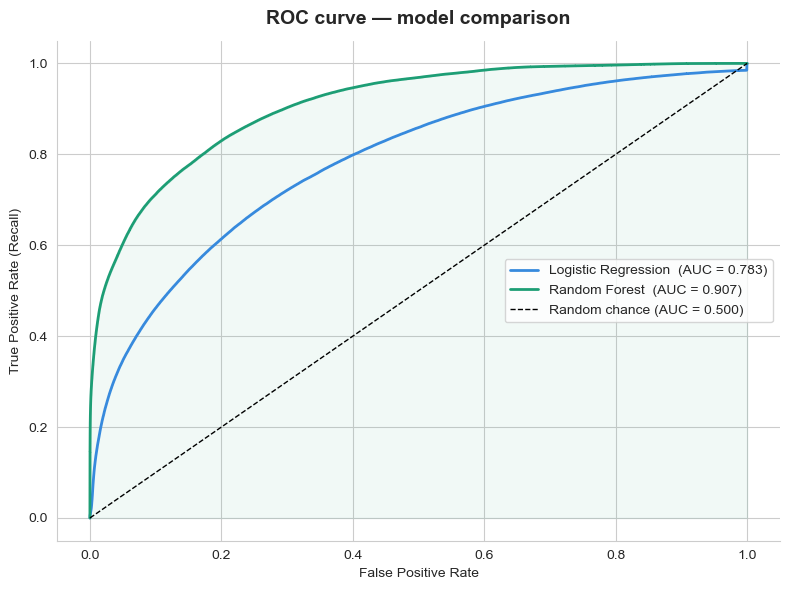

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, label, color in [
    (y_prob_lr, "Logistic Regression", "#378ADD"),
    (y_prob_rf, "Random Forest",       "#1D9E75"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{label}  (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random chance (AUC = 0.500)")
ax.fill_between(*roc_curve(y_test, y_prob_rf)[:2],
                alpha=0.06, color="#1D9E75")

ax.set_title("ROC curve — model comparison",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend(frameon=True, fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

### Feature Importance

#### The top features reveal which operational factors the model relies on most. Features highlighted in red are the strongest predictors. If scheduling-related features (DEPARTURE_HOUR, SCHEDULED_TIME) dominate, this suggests delay risk is driven primarily by when a flight is scheduled, not just who operates it — a finding with direct operational implications for schedule design and resource allocation.

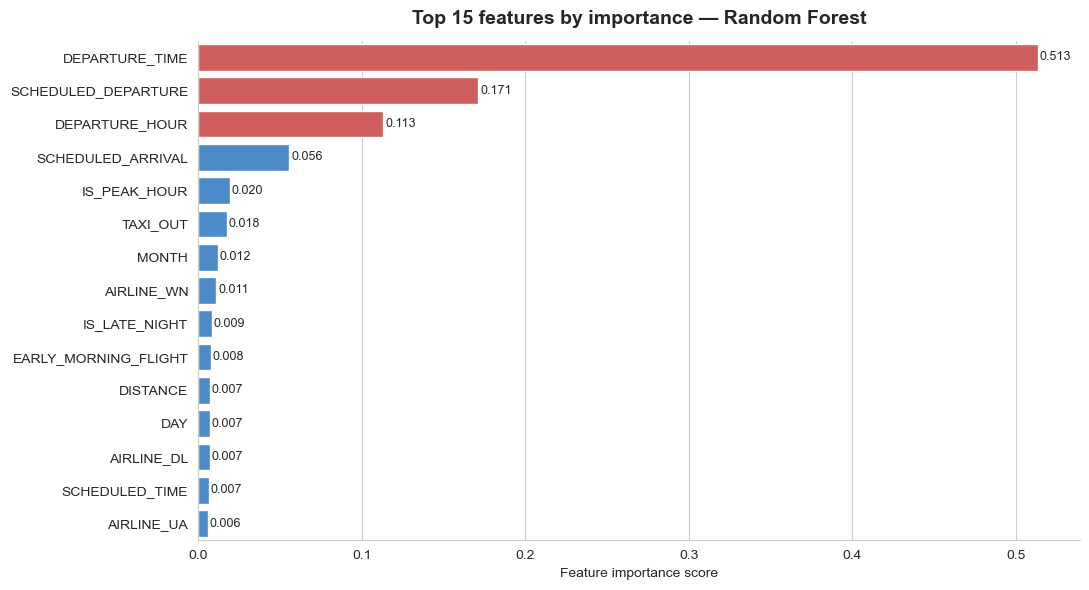

In [12]:
importance_df = pd.DataFrame({
    "Feature":    feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#E24B4A" if i < 3 else "#378ADD"
          for i in range(len(importance_df))]
sns.barplot(data=importance_df,
            x="Importance", y="Feature",
            palette=colors, ax=ax)

for bar, val in zip(ax.patches, importance_df["Importance"]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_title("Top 15 features by importance — Random Forest",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Feature importance score")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

### Decision Support

In [13]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
rows = []

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)
    rows.append({
        "Threshold":  t,
        "Precision":  round(precision_score(y_test, y_pred_t, zero_division=0), 3),
        "Recall":     round(recall_score(y_test, y_pred_t, zero_division=0), 3),
        "F1":         round(f1_score(y_test, y_pred_t, zero_division=0), 3),
        "Alerts (%)": round((y_pred_t.sum() / len(y_pred_t)) * 100, 1),
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df.to_string(index=False))
print()
print("Recommended operational threshold: 0.40")
print("Reason: Maximises recall (catching real delays) while")
print("keeping alert volume operationally manageable.")

 Threshold  Precision  Recall    F1  Alerts (%)
       0.3      0.250   0.991 0.400        71.3
       0.4      0.321   0.959 0.481        53.9
       0.5      0.460   0.846 0.596        33.1
       0.6      0.723   0.606 0.660        15.1
       0.7      0.953   0.315 0.474         6.0

Recommended operational threshold: 0.40
Reason: Maximises recall (catching real delays) while
keeping alert volume operationally manageable.


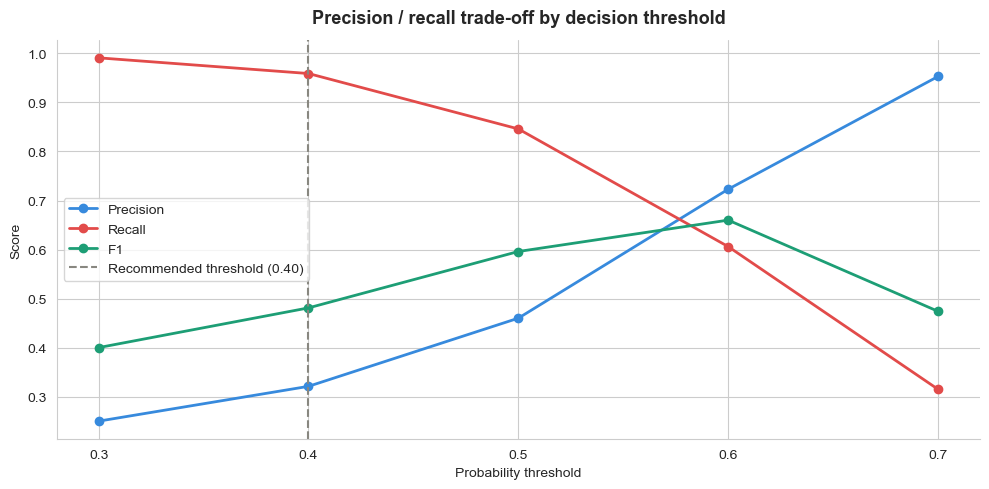

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(threshold_df["Threshold"], threshold_df["Precision"],
        marker="o", label="Precision", color="#378ADD", lw=2)
ax.plot(threshold_df["Threshold"], threshold_df["Recall"],
        marker="o", label="Recall",    color="#E24B4A",  lw=2)
ax.plot(threshold_df["Threshold"], threshold_df["F1"],
        marker="o", label="F1",        color="#1D9E75",  lw=2)
ax.axvline(0.40, linestyle="--", color="#888780",
           lw=1.5, label="Recommended threshold (0.40)")

ax.set_title("Precision / recall trade-off by decision threshold",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Score")
ax.set_xticks(thresholds)
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

In [15]:
THRESHOLD = 0.40

risk_output = X_test.copy()
risk_output["DELAY_RISK_PROB"]  = y_prob_rf.round(3)
risk_output["DELAY_RISK_LABEL"] = np.where(
    y_prob_rf >= THRESHOLD, "HIGH RISK", "LOW RISK"
)
risk_output["ACTUAL"] = y_test.values

high_risk = risk_output[risk_output["DELAY_RISK_LABEL"] == "HIGH RISK"]
low_risk  = risk_output[risk_output["DELAY_RISK_LABEL"] == "LOW RISK"]

print(f"Flights flagged as HIGH RISK : {len(high_risk):,}  "
      f"({len(high_risk)/len(risk_output)*100:.1f}%)")
print(f"Flights flagged as LOW RISK  : {len(low_risk):,}  "
      f"({len(low_risk)/len(risk_output)*100:.1f}%)")
print()
print("Sample high-risk flights:")
print(high_risk[["DELAY_RISK_PROB","DELAY_RISK_LABEL","ACTUAL"]]
      .sort_values("DELAY_RISK_PROB", ascending=False)
      .head(10).to_string())

Flights flagged as HIGH RISK : 574,973  (53.9%)
Flights flagged as LOW RISK  : 491,610  (46.1%)

Sample high-risk flights:
         DELAY_RISK_PROB DELAY_RISK_LABEL  ACTUAL
3095533            0.943        HIGH RISK       1
2688577            0.942        HIGH RISK       1
116362             0.942        HIGH RISK       1
2064515            0.941        HIGH RISK       1
3129315            0.940        HIGH RISK       1
4646301            0.940        HIGH RISK       1
2419309            0.940        HIGH RISK       1
660069             0.939        HIGH RISK       1
3433671            0.937        HIGH RISK       1
1542007            0.937        HIGH RISK       1


In [16]:
import pickle

with open("flight_delay_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("flight_delay_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("flight_delay_feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

print("Saved:")
print("  flight_delay_model.pkl")
print("  flight_delay_scaler.pkl")
print("  flight_delay_feature_names.pkl")

Saved:
  flight_delay_model.pkl
  flight_delay_scaler.pkl
  flight_delay_feature_names.pkl


#### Random Forest
- Decision Threshold: 0.40

- Random Forest was selected as the preferred production candidate because it delivered stronger recall and better overall balance between precision and operational usefulness.

- Rather than using the default classification threshold of 0.50, the threshold was intentionally reduced to 0.40 to better align with business priorities.

- This improves the model’s ability to identify potentially delayed flights earlier, even at the cost of generating more operational alerts.

- In aviation operations, missing a true delay event is typically more costly than investigating a false positive. For this reason, recall was prioritised over raw accuracy.

### Business Interpretation

- The model predicts elevated delay risk before departure, using only pre-flight operational data such as:

- scheduled departure timing
- peak-hour congestion indicators
- airline operational patterns
- airport hub activity
- route characteristics
- seasonal and temporal travel patterns

### Limitations and Next Steps
- Current limitations
- Model is trained on historical U.S. flight data (2015) and would require retraining for live deployment
- External operational variables such as live weather feeds are not included
- Aircraft rotation dependency and inbound aircraft status are not captured
- Real-world deployment would require continuous monitoring for model drift

### Recommended next improvements
- integrate live weather APIs
- include aircraft tail-number rotation chains
- incorporate airport congestion signals
- monitor real-time operational feedback loops
- establish retraining schedules for seasonal adaptation

These additions would significantly improve production-level reliability.

### Final Project Conclusion

- This project demonstrates how predictive modelling can move airline operations from reactive delay management to proactive operational control.

- By identifying high-risk flights before departure, airlines can reduce disruption, improve passenger experience, and optimise network efficiency.

- The final notebook will translate these modelling outcomes into a formal Business Decision Framework, showing how machine learning supports real operational strategy rather than existing only as a technical exercise.